In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor

In [3]:
df=pd.read_csv("car_fuel_efficiency.csv")

In [4]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [5]:
df = df.fillna(0)

In [6]:
df_full_train, df_temp = train_test_split(df, test_size=0.4, random_state=1)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=1)

In [7]:
y_train = df_full_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

X_train = df_full_train.drop('fuel_efficiency_mpg', axis=1)
X_val = df_val.drop('fuel_efficiency_mpg', axis=1)
X_test = df_test.drop('fuel_efficiency_mpg', axis=1)

In [8]:
dv = DictVectorizer(sparse=True)

train_dicts = X_train.to_dict(orient='records')
X_train_matrix = dv.fit_transform(train_dicts)

val_dicts = X_val.to_dict(orient='records')
X_val_matrix = dv.transform(val_dicts)

## **Question 1**
Let's train a decision tree regressor to predict the fuel_efficiency_mpg variable.

- Train a model with max_depth=1.

Which feature is used for splitting the data?

- 'vehicle_weight'
- 'model_year'
- 'origin'
- 'fuel_type'

In [9]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train_matrix, y_train)

DecisionTreeRegressor(max_depth=1)

In [10]:
feature_names = dv.get_feature_names_out()
split_feature = feature_names[dt.tree_.feature[0]]
print("Feature yang dipake buat split:", split_feature)

Feature yang dipake buat split: vehicle_weight


## **Question 2**
Train a random forest regressor with these parameters:

- n_estimators=10
- random_state=1
- n_jobs=-1 (optional - to make training faster)

What's the RMSE of this model on the validation data?

- 0.045
- 0.45
- 4.5
- 45.0

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

In [12]:
rf = RandomForestRegressor(
    n_estimators=10,
    random_state=1,
    n_jobs=-1
)

rf.fit(X_train_matrix, y_train)

RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)

In [13]:
y_pred = rf.predict(X_val_matrix)

In [14]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE:", rmse)

RMSE: 0.4602815367032658


## **Question 3**
Now let's experiment with the n_estimators parameter

- Try different values of this parameter from 10 to 200 with step 10.
- Set random_state to 1.
- Evaluate the model on the validation dataset.

After which value of n_estimators does RMSE stop improving? Consider 3 decimal places for calculating the answer.
- 10
- 25
- 80
- 200

If it doesn't stop improving, use the latest iteration number in your answer.

In [15]:
rmse_list = []

for n in range(10, 201, 10):
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=1,
        n_jobs=-1
    )
    rf.fit(X_train_matrix, y_train)
    y_pred = rf.predict(X_val_matrix)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_list.append((n, rmse))
    print(f"n_estimators={n}: RMSE={rmse:.3f}")

n_estimators=10: RMSE=0.460
n_estimators=20: RMSE=0.446
n_estimators=30: RMSE=0.440
n_estimators=40: RMSE=0.438
n_estimators=50: RMSE=0.437
n_estimators=60: RMSE=0.436
n_estimators=70: RMSE=0.436
n_estimators=80: RMSE=0.436
n_estimators=90: RMSE=0.435
n_estimators=100: RMSE=0.435
n_estimators=110: RMSE=0.435
n_estimators=120: RMSE=0.435
n_estimators=130: RMSE=0.435
n_estimators=140: RMSE=0.435
n_estimators=150: RMSE=0.435
n_estimators=160: RMSE=0.435
n_estimators=170: RMSE=0.435
n_estimators=180: RMSE=0.435
n_estimators=190: RMSE=0.435
n_estimators=200: RMSE=0.435


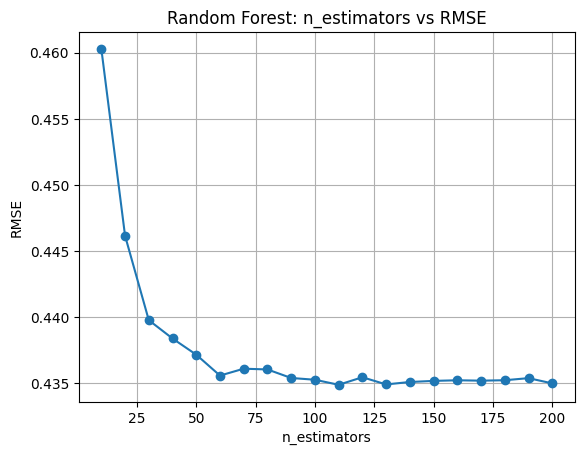

In [24]:
import matplotlib.pyplot as plt

n_values = [n for n, _ in rmse_list]
rmse_values = [rmse for _, rmse in rmse_list]

plt.plot(n_values, rmse_values, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('Random Forest: n_estimators vs RMSE')
plt.grid(True)
plt.show()

## **Question 4**
Let's select the best max_depth:

- Try different values of max_depth: [10, 15, 20, 25]
For each of these values,
- try different values of n_estimators from 10 till 200 (with step 10)
    - calculate the mean RMSE
    - Fix the random seed: random_state=1

What's the best max_depth, using the mean RMSE?
- 10
- 15
- 20
- 25

In [16]:
depths = [10, 15, 20, 25]
rmse_scores = {}

for d in depths:
    rmses = []
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=d,
            random_state=1,
            n_jobs=-1
        )
        rf.fit(X_train_matrix, y_train)
        y_pred = rf.predict(X_val_matrix)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmses.append(rmse)
    rmse_scores[d] = np.mean(rmses)
    print(f"max_depth={d}: mean RMSE={np.mean(rmses):.3f}")

max_depth=10: mean RMSE=0.436
max_depth=15: mean RMSE=0.438
max_depth=20: mean RMSE=0.438
max_depth=25: mean RMSE=0.438


## **Question 5**
We can extract feature importance information from tree-based models.

At each step of the decision tree learning algorithm, it finds the best split. When doing it, we can calculate "gain" - the reduction in impurity before and after the split. This gain is quite useful in understanding what are the important features for tree-based models.
In Scikit-Learn, tree-based models contain this information in the feature_importances_ field.
For this homework question, we'll find the most important feature:
- Train the model with these parameters:
    - n_estimators=10,
    - max_depth=20,
    - random_state=1,
    - n_jobs=-1 (optional)
- Get the feature importance information from this model

What's the most important feature (among these 4)?
- vehicle_weight
- horsepower
- acceleration
- engine_displacement

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=1,
    n_jobs=-1
)

rf.fit(X_train_matrix, y_train)

RandomForestRegressor(max_depth=20, n_estimators=10, n_jobs=-1, random_state=1)

In [18]:
feature_names = dv.get_feature_names_out()

importances = rf.feature_importances_

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

fi = fi.sort_values(by='importance', ascending=False)

print(fi.head(10))

                feature  importance
13       vehicle_weight    0.959878
6            horsepower    0.015933
0          acceleration    0.011442
3   engine_displacement    0.003159
7            model_year    0.003066
8         num_cylinders    0.002323
9             num_doors    0.001576
12           origin=USA    0.000496
10          origin=Asia    0.000431
11        origin=Europe    0.000419


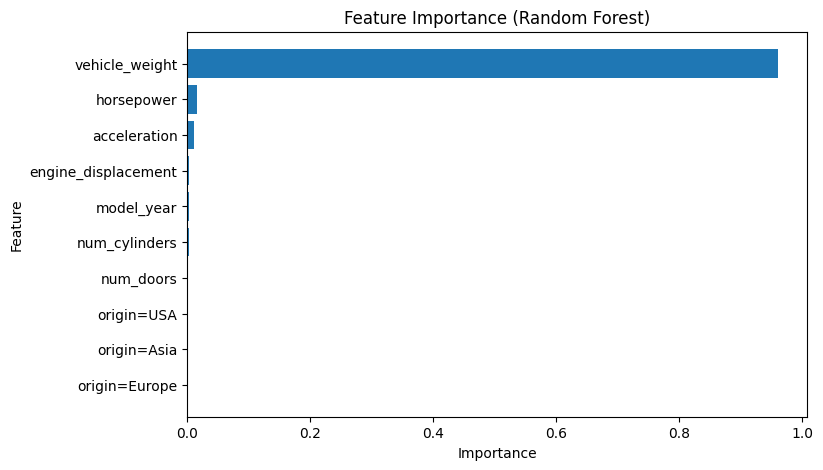

In [26]:
plt.figure(figsize=(8,5))
plt.barh(fi['feature'][:10], fi['importance'][:10])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

## **Question 6**

Now let's train an XGBoost model! For this question, we'll tune the eta parameter:

Install XGBoost
Create DMatrix for train and validation
Create a watchlist
Train a model with these parameters for 100 rounds:

```
xgb_params = {

    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,

}
```

Now change eta from 0.3 to 0.1.

Which eta leads to the best RMSE score on the validation dataset?

- 0.3
- 0.1
- Both give equal value


In [19]:
import xgboost as xgb

In [20]:
dtrain = xgb.DMatrix(X_train_matrix, label=y_train)
dval = xgb.DMatrix(X_val_matrix, label=y_val)

In [21]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [22]:
xgb_params_03 = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1
}

model_03 = xgb.train(xgb_params_03, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=False)

y_pred_03 = model_03.predict(dval)
rmse_03 = np.sqrt(mean_squared_error(y_val, y_pred_03))
print("RMSE (eta=0.3):", rmse_03)

RMSE (eta=0.3): 0.44340462733166064


In [23]:
xgb_params_01 = xgb_params_03.copy()
xgb_params_01['eta'] = 0.1

model_01 = xgb.train(xgb_params_01, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=False)

y_pred_01 = model_01.predict(dval)
rmse_01 = np.sqrt(mean_squared_error(y_val, y_pred_01))
print("RMSE (eta=0.1):", rmse_01)

RMSE (eta=0.1): 0.4167428683326873


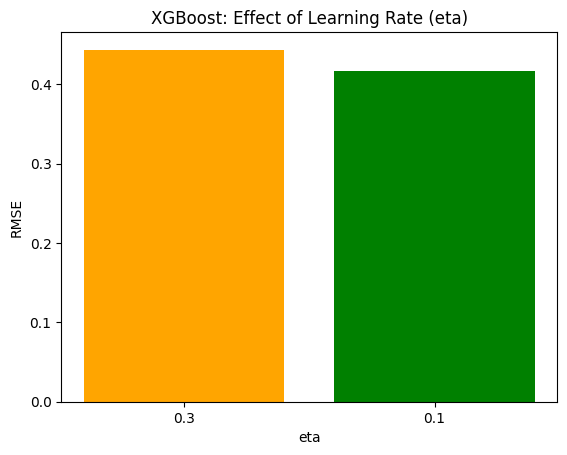

In [27]:
etas = ['0.3', '0.1']
rmses = [rmse_03, rmse_01]

plt.bar(etas, rmses, color=['orange', 'green'])
plt.xlabel('eta')
plt.ylabel('RMSE')
plt.title('XGBoost: Effect of Learning Rate (eta)')
plt.show()